In [9]:
from neo4j import GraphDatabase

# Initialize connection to the PuppyGraph.
uri = "bolt://localhost:7687"
username = "puppygraph"
password = "puppygraph123"
driver = GraphDatabase.driver(uri, auth=(username, password))
session = driver.session()

# Get all nodes from the graph.
query = """MATCH (n) WITH n LIMIT 10
MATCH (n)-[r]->(m) RETURN n, r, m
"""
results = session.run(query)

print("All nodes in the graph:")
for record in results:
    node = record["n"]
    print({
        "id": node.element_id,
        "labels": list(node.labels),
        "properties": dict(node._properties)
    })

All nodes in the graph:
{'id': 'node[10]', 'labels': ['node'], 'properties': {}}
{'id': 'node[10]', 'labels': ['node'], 'properties': {}}
{'id': 'node[10]', 'labels': ['node'], 'properties': {}}
{'id': 'node[10]', 'labels': ['node'], 'properties': {}}
{'id': 'node[10]', 'labels': ['node'], 'properties': {}}
{'id': 'node[10]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 'node[12]', 'labels': ['node'], 'properties': {}}
{'id': 

In [10]:
import networkx as nx
G = nx.MultiDiGraph()

nodes = list(results.graph()._nodes.values())
for node in nodes:
    G.add_node(node.id, labels=node._labels, properties=node._properties)

rels = list(results.graph()._relationships.values())
for rel in rels:
    G.add_edge(rel.start_node.id, rel.end_node.id, key=rel.id, type=rel.type, properties=rel._properties)

/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_4085/2338988782.py:6: DeprecationWarning: `id` is deprecated, use `element_id` instead
  G.add_node(node.id, labels=node._labels, properties=node._properties)
/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_4085/2338988782.py:10: DeprecationWarning: `id` is deprecated, use `element_id` instead
  G.add_edge(rel.start_node.id, rel.end_node.id, key=rel.id, type=rel.type, properties=rel._properties)


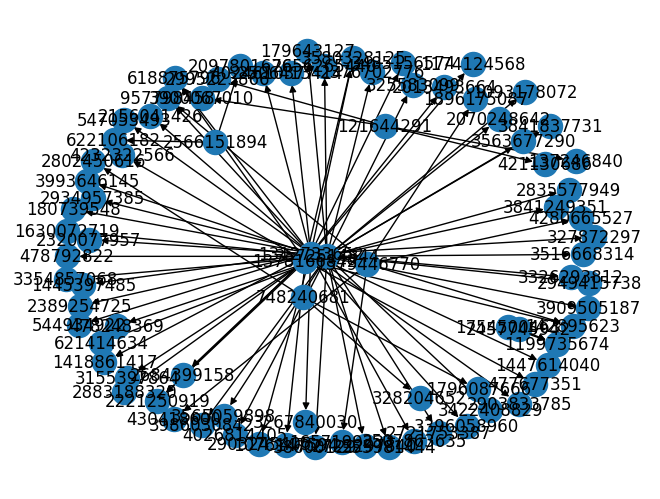

In [12]:
nx.draw(G, with_labels=True)